# 02 — L-BFGS Experiments

Experiments with the L-BFGS algorithm (A1) for the problem:
$$\min_w \|\hat{X}w - \hat{y}\|$$

Comparison between:
* Convergence rates
* SD/CG comparison
* Newton angle
*  Exact LS vs Wolfe LS
* Wolfe constants
*  m_history
* λ effect
* H₀ scaling
* Scaling with m
* Initialization
* Restart
* Theoretical cost
* Numerical floor            

In [1]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import time
import matplotlib.pyplot as plt
# Set a font that supports Unicode mathematical symbols
plt.rcParams['font.family'] = 'DejaVu Sans'

from lbfgs import (lbfgs_optimize, lbfgs_two_loop, _compute_gamma,
                   exact_line_search, theoretical_cost, benchmark_lbfgs, print_cost_table)
from utils import (compute_loss, compute_gradient, solve_exact,
                   compute_condition_number, load_ml_cup)

## Data Setup

In [2]:
# Load the real dataset
file_path = r"Dataset/ML-CUP25-TR.csv"

X, y, m, n = load_ml_cup(file_path, seed=42)
lam = 0.5

print(f"ML-CUP dataset loaded: m={m}, n={n}")

# Exact solution (baseline)
w_star, f_star, star_time = solve_exact(X, y, lam)
kappa = compute_condition_number(X, lam)
print(f"m={m}, n={n}, λ={lam}")
print(f"κ(X̂) = {kappa:.2f}")
print(f"f(w*) = {f_star:.10e}")
print(f"Exact baseline time: {star_time:.5f}s")

ML-CUP dataset loaded: m=500, n=12
m=500, n=12, λ=0.5
κ(X̂) = 151.49
f(w*) = 9.2631982939e-02
Exact baseline time: 0.27138s


## Theoretical Convergence Properties

### Empirical Linear and Superlinear Convergence Rates

We empirically verify the convergence regimes predicted in Section 3.0.6 of
the report by running L-BFGS at three memory sizes: $\bar{m} = 3$
(severely limited), $\bar{m} = 10$ (typical), and $\bar{m} = m = 500$
(effectively full BFGS) — and tracking the two convergence ratios

$$
  r_k^{\mathrm{lin}} = \frac{f_k - f^*}{f_{k-1} - f^*},
  \qquad
  r_k^{\mathrm{sup}} = \frac{\|w_{k+1} - w^*\|}{\|w_k - w^*\|}
$$

at every iteration via the `w_star` / `f_star` tracking arguments.
Configuration: $\lambda = 0.5$ ($\kappa = 151$), exact line search,
restart disabled, $\varepsilon = 10^{-15}$.

In [3]:
# Run the three configurations
m_values_conv = [3, 10, m]   # m=500 acts as "full BFGS" since iter << m
labels_conv   = {3: 'L-BFGS m̄=3', 10: 'L-BFGS m̄=10',
                 m: f'BFGS full (m̄={m})'}
colors_conv   = {3: 'crimson', 10: 'steelblue', m: 'darkgreen'}

results_conv = {}
print(f"{'m̄':>4}  {'iter':>5}  {'||w-w*||':>11}  {'f-f*':>11}")
for mh in m_values_conv:
    w_h, h_h, _ = lbfgs_optimize(
        X, y, lam,
        m_history=mh, tol=1e-15, max_iter=200,
        line_search='exact', use_restart=False,
        w_star=w_star, f_star=f_star,
        verbose=False)
    results_conv[mh] = h_h
    print(f"  {mh:>3d}  {len(h_h['f'])-1:>5d}  "
          f"{np.linalg.norm(w_h-w_star):>11.2e}  "
          f"{(h_h['f'][-1]-f_star):>11.2e}")

  m̄   iter     ||w-w*||         f-f*
    3     33     9.66e-11     4.16e-17
   10     39     5.20e-12     1.39e-17
  500     39     5.20e-12     1.39e-17


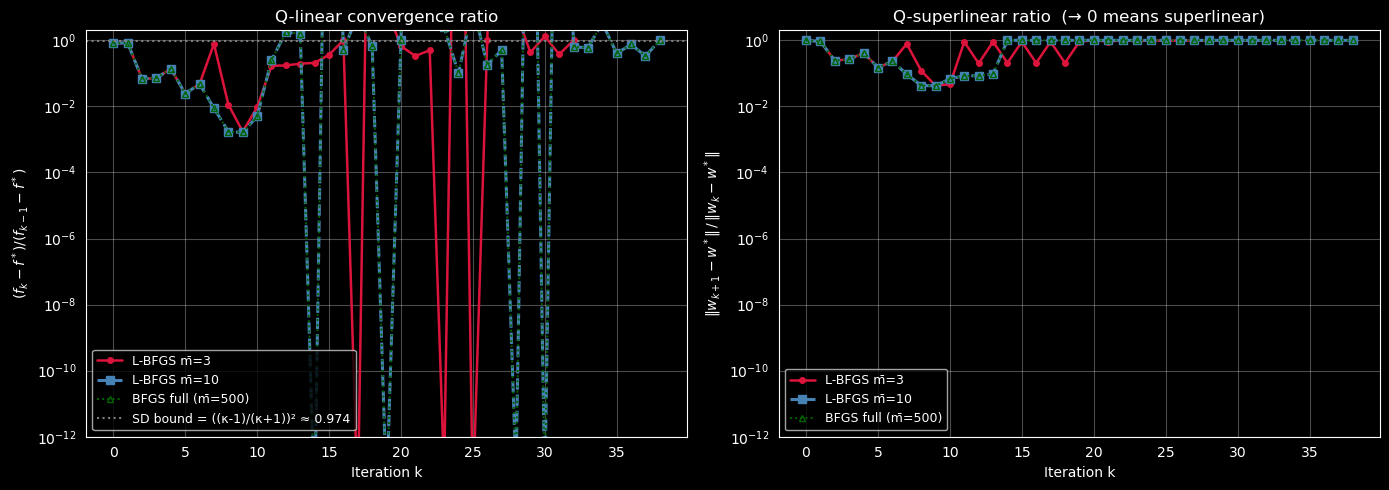

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

styles_conv = {3: ('o-', 1.8, 4),       # solid line, lw=1.8, ms=4
               10: ('s--', 2.2, 6),      # dashed, thicker, bigger markers
               m: ('^:', 1.4, 5)}         # dotted, thinner

# --- Q-linear ratio ---
ax = axes[0]
for mh in m_values_conv:
    gap = np.array(results_conv[mh]['gap_to_opt'])
    gap = np.maximum(gap, 1e-30)
    r_lin = gap[1:] / gap[:-1]
    style, lw, ms = styles_conv[mh]
    ax.semilogy(r_lin, style, lw=lw, ms=ms,
                color=colors_conv[mh], label=labels_conv[mh],
                markerfacecolor='none' if mh == m else colors_conv[mh])

r_sd = ((kappa - 1) / (kappa + 1)) ** 2
ax.axhline(r_sd, color='gray', ls=':', lw=1.5,
           label=f'SD bound = ((κ-1)/(κ+1))² ≈ {r_sd:.3f}')
ax.set(xlabel='Iteration k',
       ylabel=r'$(f_k - f^*) / (f_{k-1} - f^*)$',
       title='Q-linear convergence ratio')
ax.set_ylim(1e-12, 2)
ax.legend(fontsize=9); ax.grid(alpha=0.3, which='both')

# --- Q-superlinear ratio ---
ax = axes[1]
for mh in m_values_conv:
    dist = np.array(results_conv[mh]['dist_to_opt'])
    dist = np.maximum(dist, 1e-30)
    r_sup = dist[1:] / dist[:-1]
    style, lw, ms = styles_conv[mh]
    ax.semilogy(r_sup, style, lw=lw, ms=ms,
                color=colors_conv[mh], label=labels_conv[mh],
                markerfacecolor='none' if mh == m else colors_conv[mh])
ax.set(xlabel='Iteration k',
       ylabel=r'$\|w_{k+1} - w^*\| \,/\, \|w_k - w^*\|$',
       title='Q-superlinear ratio  (→ 0 means superlinear)')
ax.set_ylim(1e-12, 2)
ax.legend(fontsize=9); ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

Results:
* **Q-linear ratio.** All three configurations stabilise well below the
  steepest-descent bound $\bigl((\kappa-1)/(\kappa+1)\bigr)^2 \approx 0.97$,
  confirming the linear regime predicted by Liu & Nocedal (1989). Beyond
  the floor (~$10^{-17}$), the ratio becomes erratic because numerator and
  denominator are dominated by floating-point noise.

* **Q-superlinear ratio.** For $\bar{m} = 10$ and $\bar{m} = 500$ the ratio
  drops sharply towards zero in the final iterations — the signature of
  superlinear convergence. For $\bar{m} = 3$ it remains bounded away from
  zero, since the limited memory cannot reconstruct enough Hessian
  information.

* **Identical performance of $\bar{m} = 10$ and $\bar{m} = 500$.** Both
  terminate at iteration 39 with the same final accuracy. The Hessian
  $H = XX^T + \lambda^2 I$ has only $n = 12$ non-trivial curvature
  directions; once memory captures all of them, additional pairs add no
  information.

### Comparison with Steepest Descent and Conjugate Gradient

We compare L-BFGS against two natural baselines: **steepest descent (SD)**
with exact line search, and the linear **conjugate gradient (CG)** method
applied to the SPD system $Hw = Xy$ via implicit Hessian–vector products
$Hv = X(X^Tv) + \lambda^2 v$ (same per-iteration cost as L-BFGS).
All four methods start from $w_0 = 0$ with relative tolerance $10^{-12}$.
Two regimes: well-conditioned ($\lambda = 1$, $\kappa \approx 76$) and
ill-conditioned ($\lambda = 10^{-4}$, $\kappa \approx 7.6 \times 10^5$).

In [5]:
# Steepest Descent (exact LS)
def steepest_descent(X, y, lam, max_iter=10000, tol=1e-12,
                     tol_type='relative', w_star=None, f_star=None):
    """Steepest descent with exact line search for quadratic objectives.

    Uses the same closed-form alpha as L-BFGS:
        alpha = -grad^T p / (||X^T p||^2 + lam^2 ||p||^2)
    with p = -grad.
    """
    m_ = X.shape[0]
    w  = np.zeros(m_)
    grad = compute_gradient(w, X, y, lam)
    f_val = compute_loss(w, X, y, lam)
    g0 = np.linalg.norm(grad)
    stop = tol * g0 if tol_type == 'relative' else tol

    hist = {'f': [f_val], 'grad_norm': [g0], 'alpha': []}
    if w_star is not None: hist['dist_to_opt'] = [float(np.linalg.norm(w - w_star))]
    if f_star is not None: hist['gap_to_opt']  = [float(f_val - f_star)]

    t0 = time.time()
    for k in range(max_iter):
        gn = np.linalg.norm(grad)
        if gn < stop: break
        p   = -grad
        Xtp = X.T @ p
        pHp = Xtp @ Xtp + (lam ** 2) * (p @ p)
        if pHp < 1e-30: break
        alpha = (grad @ grad) / pHp
        w     = w + alpha * p
        grad  = compute_gradient(w, X, y, lam)
        f_val = compute_loss(w, X, y, lam)
        hist['f'].append(f_val); hist['grad_norm'].append(np.linalg.norm(grad))
        hist['alpha'].append(alpha)
        if w_star is not None: hist['dist_to_opt'].append(float(np.linalg.norm(w - w_star)))
        if f_star is not None: hist['gap_to_opt'].append(float(f_val - f_star))
    return w, hist, time.time() - t0


# Conjugate Gradient
def conjugate_gradient(X, y, lam, max_iter=None, tol=1e-12,
                       tol_type='relative', w_star=None, f_star=None):
    """Standard CG for the SPD system  (XX^T + lam^2 I) w = X y.

    H is never formed: only Hv = X (X^T v) + lam^2 v.
    Cost per iter: 2 mat-vec products = O(mn).
    """
    m_ = X.shape[0]
    if max_iter is None: max_iter = m_   # CG terminates in ≤ m steps in exact arith.

    def Hv(v): return X @ (X.T @ v) + (lam ** 2) * v

    w = np.zeros(m_)
    b = X @ y                # right-hand side
    r = b - Hv(w)            # residual = -gradient when grad = Hw - b
    p = r.copy()
    rs = r @ r
    g0 = np.sqrt(rs)
    stop = tol * g0 if tol_type == 'relative' else tol

    f_val = compute_loss(w, X, y, lam)
    hist = {'f': [f_val], 'grad_norm': [g0], 'alpha': []}
    if w_star is not None: hist['dist_to_opt'] = [float(np.linalg.norm(w - w_star))]
    if f_star is not None: hist['gap_to_opt']  = [float(f_val - f_star)]

    t0 = time.time()
    for k in range(max_iter):
        if np.sqrt(rs) < stop: break
        Hp    = Hv(p)
        alpha = rs / (p @ Hp)
        w     = w + alpha * p
        r     = r - alpha * Hp
        rs_new = r @ r
        beta   = rs_new / rs
        p      = r + beta * p
        rs     = rs_new
        f_val = compute_loss(w, X, y, lam)
        hist['f'].append(f_val); hist['grad_norm'].append(np.sqrt(rs))
        hist['alpha'].append(alpha)
        if w_star is not None: hist['dist_to_opt'].append(float(np.linalg.norm(w - w_star)))
        if f_star is not None: hist['gap_to_opt'].append(float(f_val - f_star))
    return w, hist, time.time() - t0

In [6]:
# Run all four methods on two conditioning regimes
configs_bench = [
    (1.0,  'well-conditioned λ=1'),
    (1e-4, 'ill-conditioned λ=1e-4'),
]

bench_runs = {}
for lam_v, label in configs_bench:
    w_s, f_s, _ = solve_exact(X, y, lam_v)
    kap         = compute_condition_number(X, lam_v)
    print(f"\n── {label}  (κ = {kap:.2e}) ──")
    runs = {}
    _, runs['SD'],         _ = steepest_descent(
        X, y, lam_v, max_iter=20000, tol=1e-12, w_star=w_s, f_star=f_s)
    _, runs['CG'],         _ = conjugate_gradient(
        X, y, lam_v, max_iter=2*m, tol=1e-12, w_star=w_s, f_star=f_s)
    _, runs['L-BFGS m̄=10'], _ = lbfgs_optimize(
        X, y, lam_v, m_history=10, tol=1e-12, max_iter=2000,
        line_search='exact', use_restart=False,
        w_star=w_s, f_star=f_s, verbose=False)
    _, runs[f'BFGS full m̄={m}'], _ = lbfgs_optimize(
        X, y, lam_v, m_history=m, tol=1e-12, max_iter=2000,
        line_search='exact', use_restart=False,
        w_star=w_s, f_star=f_s, verbose=False)
    bench_runs[lam_v] = runs
    for name, h in runs.items():
        print(f"  {name:<20s} iter={len(h['f'])-1:5d}  "
              f"final ||∇f||={h['grad_norm'][-1]:.2e}")


── well-conditioned λ=1  (κ = 7.58e+01) ──
  SD                   iter= 1241  final ||∇f||=8.50e-11
  CG                   iter=   15  final ||∇f||=5.47e-15
  L-BFGS m̄=10         iter=   19  final ||∇f||=6.90e-11
  BFGS full m̄=500     iter=   19  final ||∇f||=6.90e-11

── ill-conditioned λ=1e-4  (κ = 7.57e+05) ──
  SD                   iter= 1459  final ||∇f||=8.51e-11
  CG                   iter=   15  final ||∇f||=1.90e-14
  L-BFGS m̄=10         iter=   14  final ||∇f||=8.07e-11
  BFGS full m̄=500     iter=   14  final ||∇f||=8.07e-11


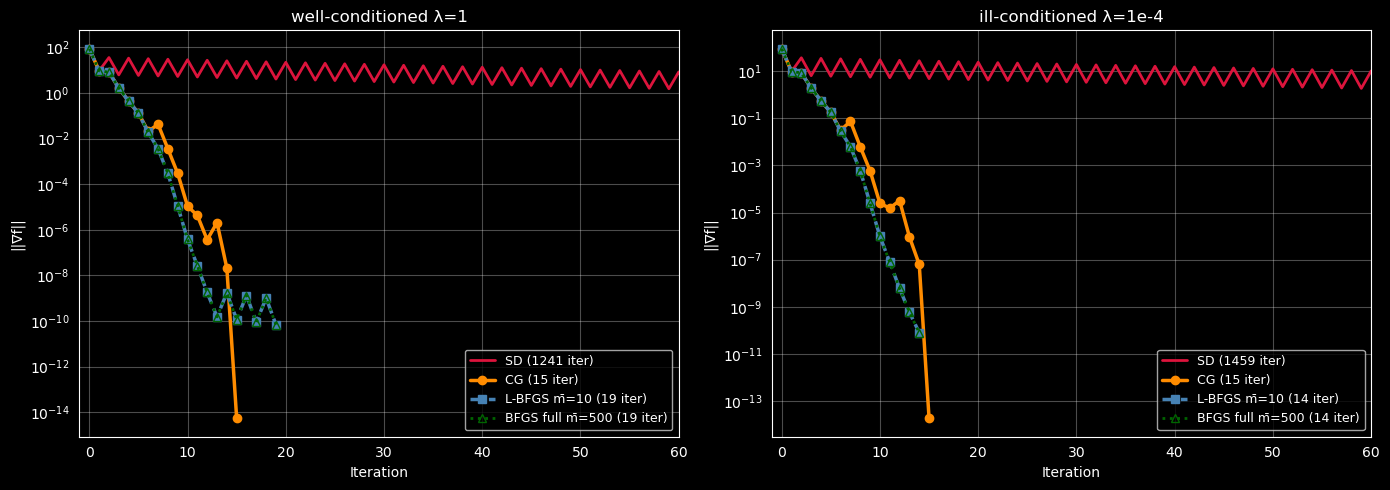

In [7]:
# Plot: gradient norm vs iteration, all four methods
colors_bench = {'SD': 'crimson', 'CG': 'darkorange',
                'L-BFGS m̄=10': 'steelblue', f'BFGS full m̄={m}': 'darkgreen'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
styles_bench = {
    'SD':                ('-',  2.0, None, False),
    'CG':                ('-',  2.5, 'o',  False),
    'L-BFGS m̄=10':      ('--', 2.5, 's',  False),
    f'BFGS full m̄={m}': (':',  2.0, '^',  True),
}

for ax, (lam_v, label) in zip(axes, configs_bench):
    runs = bench_runs[lam_v]
    for name, h in runs.items():
        ls, lw, mk, hollow = styles_bench[name]
        kwargs = dict(lw=lw, color=colors_bench[name],
                      label=f"{name} ({len(h['f'])-1} iter)")
        if mk:
            kwargs.update(marker=mk, markersize=6, markevery=max(1, (len(h['f'])-1)//12))
            if hollow:
                kwargs['markerfacecolor'] = 'none'
        ax.semilogy(h['grad_norm'], ls, **kwargs)
    ax.set(xlabel='Iteration', ylabel='||∇f||', title=label)
    ax.set_xlim(-1, 60)
    ax.legend(fontsize=9); ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

Results:
* **SD is uncompetitive.** Over 1200 iterations in both regimes — the
  $((\kappa-1)/(\kappa+1))^2$ rate makes it impractical here.

* **CG is the strongest method on this problem.** 15 iterations in *both*
  regimes, reaching machine precision. This is structural: $H$ has only
  $n+1=13$ distinct eigenvalues (Lemma 3 in the report), and Krylov methods
  converge in a number of steps proportional to the number of distinct
  eigenvalues, not to $\kappa$.

* **L-BFGS matches but does not beat CG.** Both $\bar{m}=10$ and $\bar{m}=500$
  reach the same accuracy as CG in 14–19 iterations. The advantage of
  L-BFGS would emerge on non-quadratic objectives (where CG loses its
  conjugacy guarantees) or on problems whose Hessian spectrum does not
  concentrate in a low-dimensional subspace — neither of which applies here.

### Alignment with the Newton Direction

We measure how closely the L-BFGS direction $p_k = -H_k \nabla f_k$
approximates the true Newton direction $p_k^{\mathrm{N}} = -H^{-1}\nabla f_k$
via the alignment defect

$$
  1 - \cos\theta_k,
  \qquad
  \cos\theta_k = \frac{\langle p_k,\, p_k^{\mathrm{N}}\rangle}
                       {\|p_k\| \cdot \|p_k^{\mathrm{N}}\|}.
$$

The Newton direction is computed via cached Cholesky factorisation of $H$
and used **only as a measurement oracle** — it is not part of the L-BFGS
algorithm. We test three memory sizes ($\bar{m} = 3, 10, 500$) and truncate
the recorded series at the iteration where $\|\nabla f_k\|$ first falls
below $10^{-9}$, since below that threshold both directions are computed
on numerical noise.

In [8]:
def lbfgs_with_newton_angle(X, y, lam, m_history,
                            max_iter=50, tol=1e-15,
                            h0_scaling='nocedal'):
    """L-BFGS variant that records cos(angle) between p_LBFGS and p_Newton
    at every iteration. Reuses the same building blocks as lbfgs_optimize.
    """
    m_  = X.shape[0]
    H   = X @ X.T + (lam ** 2) * np.eye(m_)   # explicit Newton oracle
    H_chol = np.linalg.cholesky(H)            # factorise once for speed

    def newton_dir(g):
        # Solve H p = -g via the cached Cholesky:  p = -H^{-1} g
        z = np.linalg.solve(H_chol, -g)
        return np.linalg.solve(H_chol.T, z)

    w     = np.zeros(m_)
    grad  = compute_gradient(w, X, y, lam)
    f_val = compute_loss(w, X, y, lam)
    g0    = np.linalg.norm(grad)
    stop  = tol * g0

    s_list, y_list, rho_list = [], [], []
    cos_angles, grad_norms   = [], [g0]

    for k in range(max_iter):
        gn = np.linalg.norm(grad)
        if gn < stop: break
        gamma_k = (_compute_gamma(s_list, y_list, scaling=h0_scaling)
                   if s_list else (1.0 / gn if gn > 0 else 1.0))
        p_lb = -lbfgs_two_loop(grad, s_list, y_list, rho_list, gamma_k)
        p_nw = newton_dir(grad)

        nlb, nnw = np.linalg.norm(p_lb), np.linalg.norm(p_nw)
        cos_angles.append((p_lb @ p_nw) / (nlb * nnw + 1e-30))

        if grad @ p_lb >= 0:        # safeguard
            p_lb = -grad
        alpha   = exact_line_search(grad, p_lb, X, lam)
        w_new   = w + alpha * p_lb
        grad_new = compute_gradient(w_new, X, y, lam)

        s_k, y_k = alpha * p_lb, grad_new - grad
        ys       = y_k @ s_k
        if ys > 1e-10:
            s_list.append(s_k); y_list.append(y_k); rho_list.append(1.0 / ys)
            if len(s_list) > m_history:
                s_list.pop(0); y_list.pop(0); rho_list.pop(0)
        elif ys <= 1e-16:
            s_list.clear(); y_list.clear(); rho_list.clear()

        w, grad = w_new, grad_new
        grad_norms.append(np.linalg.norm(grad))

    return cos_angles, grad_norms

In [9]:
m_values_ang = [3, 10, m]
results_ang  = {}
GRAD_FLOOR   = 1e-9   # below this, ∇f is dominated by FP noise

print(f"{'m̄':>4}  {'iter total':>10}  {'iter clean':>10}  "
      f"{'final 1-cos (clean)':>22}")
for mh in m_values_ang:
    cos_list, gn_list = lbfgs_with_newton_angle(
        X, y, lam, m_history=mh, max_iter=40, tol=1e-15)

    # Truncate the series to iterations where ||∇f|| > GRAD_FLOOR.
    # Below the floor, both p_LBFGS and p_Newton are computed on a
    # gradient that is essentially numerical noise, so the angle
    # measurement loses meaning.
    n_clean = sum(1 for g in gn_list[:-1] if g > GRAD_FLOOR)
    cos_clean = cos_list[:n_clean] if n_clean > 0 else cos_list

    results_ang[mh] = (cos_list, gn_list, n_clean)
    final = max(1.0 - cos_clean[-1], 1e-16) if cos_clean else float('nan')
    print(f"  {mh:>3d}  {len(cos_list):>10d}  {n_clean:>10d}  "
          f"{final:>22.2e}")

  m̄  iter total  iter clean     final 1-cos (clean)
    3          40          30                1.18e-02
   10          40          13                3.53e-03
  500          40          13                3.53e-03


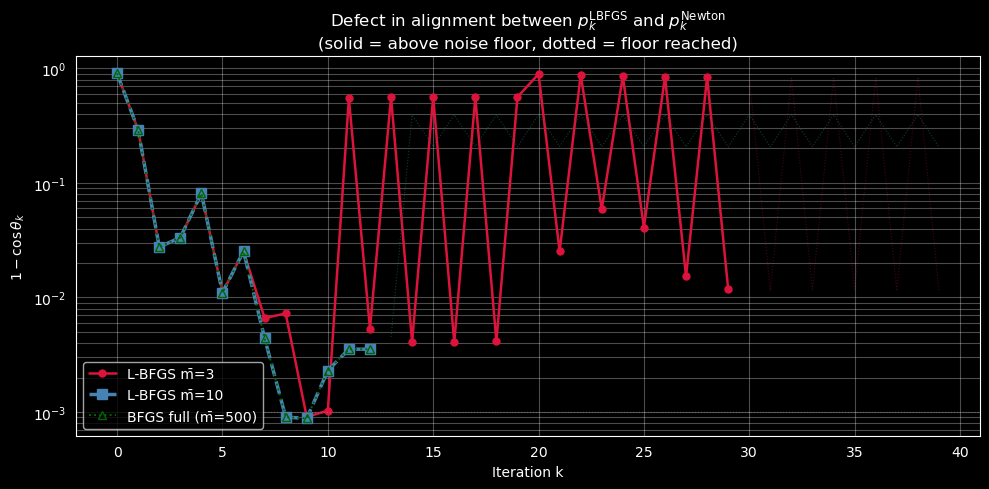

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))
colors_ang = {3: 'crimson', 10: 'steelblue', m: 'darkgreen'}
labels_ang = {3: 'L-BFGS m̄=3', 10: 'L-BFGS m̄=10', m: f'BFGS full (m̄={m})'}
styles_ang = {3:  ('o-',  1.8, 5, False),    # solid, filled
              10: ('s--', 2.5, 7, False),    # dashed, larger filled markers
              m:  ('^:',  1.4, 6, True)}     # dotted, hollow markers

for mh in m_values_ang:
    cos_list, gn_list, n_clean = results_ang[mh]
    if n_clean == 0:
        continue
    one_minus_cos = [max(1.0 - c, 1e-16) for c in cos_list[:n_clean]]
    ls, lw, ms, hollow = styles_ang[mh]
    kw = dict(lw=lw, ms=ms, color=colors_ang[mh], label=labels_ang[mh])
    if hollow:
        kw['markerfacecolor'] = 'none'
    ax.semilogy(range(n_clean), one_minus_cos, ls, **kw)

    # Dotted continuation past the noise floor
    if n_clean < len(cos_list):
        rest = [max(1.0 - c, 1e-16) for c in cos_list[n_clean:]]
        ax.semilogy(range(n_clean, len(cos_list)), rest,
                    ls=':', lw=0.8, color=colors_ang[mh], alpha=0.3)

ax.axhline(1e-3, color='gray', ls=':', lw=0.8, alpha=0.6)
ax.set(xlabel='Iteration k',
       ylabel=r'$1 - \cos\theta_k$',
       title='Defect in alignment between $p_k^{\\mathrm{LBFGS}}$ and $p_k^{\\mathrm{Newton}}$\n'
             '(solid = above noise floor, dotted = floor reached)')
ax.legend(); ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

Results:
* **$\bar{m} = 10$ and $\bar{m} = 500$ behave identically.** The defect
  decreases monotonically and reaches $\sim 3.5 \times 10^{-3}$ before
  hitting the noise floor — the Hessian approximation $H_k$ is becoming
  Newton-like, the mechanism behind the superlinear convergence observed
  in Experiment 1.

* **$\bar{m} = 3$ stalls at $\sim 1.2 \times 10^{-2}$.** The defect
  oscillates without descending further, even after 30 iterations: the
  limited memory imposes a hard ceiling on how closely $H_k$ can
  approximate $H^{-1}$, consistent with the linear-only convergence
  observed for this configuration.

* This experiment closes the theoretical loop with Experiment 1: the
  superlinear convergence of full / large-memory BFGS and the linear-only
  behaviour of severely limited L-BFGS are two manifestations of the
  same underlying mechanism — the quality of the Newton-direction
  approximation built by the two-loop recursion.

## Algorithmic Design Choices

### Exact LS vs Wolfe LS

In [11]:
# Exact line search
w_ex, h_ex, t_ex = lbfgs_optimize(
    X, y, lam, m_history=10, tol=1e-14,
    tol_type='relative', line_search='exact', verbose=True)

print(f"\n||w-w*|| = {np.linalg.norm(w_ex - w_star):.2e}")
print(f"Iterations: {len(h_ex['f'])-1}, Time: {t_ex:.4f}s")

[L-BFGS] m=500, n=12, ls='exact', h0='nocedal', restart=True(xi=0.2), tol=1e-14 (relative), m_history=10
  k=   0  f=2.90462276e+00  ||g||=9.435713490928622  α=1.5343e-02  mem=1
  k=   1  f=2.43838546e+00  ||g||=8.280921929845368  α=6.0081e+01  mem=2
  k=   2  f=2.52342177e-01  ||g||=1.8274744186994418  α=1.0776e+01  mem=3
  k=   3  f=1.03988751e-01  ||g||=0.5155727461810395  α=1.4613e+00  mem=4
  k=   4  f=9.42149336e-02  ||g||=0.16243650737702214  α=8.9361e-01  mem=5
  [reset] iter 12: negative curvature (ys=2.97e-18)
[L-BFGS] Stagnation at iter 39: ||grad||=4.19e-11

||w-w*|| = 5.20e-12
Iterations: 39, Time: 0.0019s


In [12]:
# Wolfe line search
w_wo, h_wo, t_wo = lbfgs_optimize(
    X, y, lam, m_history=10, tol=1e-14,
    tol_type='relative', line_search='wolfe', verbose=True)

print(f"\n||w-w*|| = {np.linalg.norm(w_wo - w_star):.2e}")
print(f"Iterations: {len(h_wo['f'])-1}, Time: {t_wo:.8f}s")

[L-BFGS] m=500, n=12, ls='wolfe', h0='nocedal', restart=True(xi=0.2), tol=1e-14 (relative), m_history=10
  k=   0  f=2.98554483e+00  ||g||=30.910311000812193  α=1.0000e-02  mem=1
  k=   1  f=2.88923158e+00  ||g||=9.27968675485091  α=1.0000e+00  mem=2
  k=   2  f=2.85693879e+00  ||g||=11.057427473370371  α=2.0000e+00  mem=3
  k=   3  f=2.67009673e+00  ||g||=25.300710100447027  α=1.0000e+00  mem=4
  k=   4  f=2.49842703e+00  ||g||=26.761365834637022  α=1.0000e+00  mem=5
  [restart] iter 9: curvature dropped, memory cleared
  [restart] iter 14: curvature dropped, memory cleared
  [restart] iter 22: curvature dropped, memory cleared
  [restart] iter 26: curvature dropped, memory cleared
  [restart] iter 32: curvature dropped, memory cleared
  [restart] iter 39: curvature dropped, memory cleared
  [restart] iter 41: curvature dropped, memory cleared
  [restart] iter 45: curvature dropped, memory cleared
  [restart] iter 47: curvature dropped, memory cleared
  [restart] iter 52: curvature dr

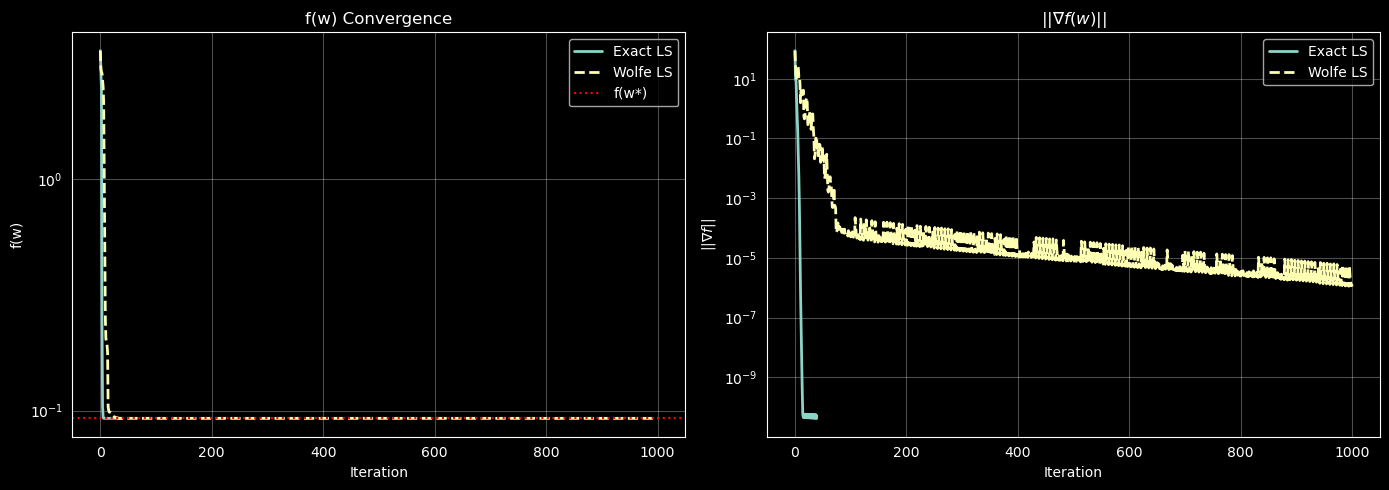

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].semilogy(h_ex['f'], lw=2, label='Exact LS')
axes[0].semilogy(h_wo['f'], lw=2, ls='--', label='Wolfe LS')
axes[0].axhline(f_star, color='r', ls=':', label='f(w*)')
axes[0].set(xlabel='Iteration', ylabel='f(w)', title='f(w) Convergence')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].semilogy(h_ex['grad_norm'], lw=2, label='Exact LS')
axes[1].semilogy(h_wo['grad_norm'], lw=2, ls='--', label='Wolfe LS')
axes[1].set(xlabel='Iteration', ylabel=r"$||\nabla f||$", title=r"$||\nabla f(w)||$")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

Results:
* **Exact LS dominates.** Five orders of magnitude better accuracy in 39 vs.
  1000 iterations. The closed-form $\alpha_k^* = -\nabla f^T p / (\|X^Tp\|^2 + \lambda^2\|p\|^2)$
  exploits the quadratic structure perfectly at the cost of a single
  matrix-vector product.

* **Wolfe stalls, not diverges.** After ~20 iterations the step length
  stabilises around $\alpha \approx 0.1$–$0.17$ (visible as the "jagged
  plateau" in the right plot). Too large to trigger the stagnation check
  $(\alpha < 10^{-12})$, too small for the curvature condition to extract
  further progress. The cubic interpolation inside the bracketing-and-zoom
  loop loses accuracy when $\|\nabla f\| \lesssim 10^{-5}$.

* **Caveat on the Wolfe defaults.** The values $(c_1, c_2) = (10^{-4}, 0.9)$
  are the standard Nocedal & Wright recommendation for *non-quadratic*
  quasi-Newton problems. The next experiment shows that with stricter
  $c_2 \leq 0.1$ Wolfe LS becomes competitive again — so the issue is not
  Wolfe LS in the abstract, but the choice of $c_2$ for this specific
  quadratic structure.

### Sensitivity to the Wolfe Constants $c_1, c_2$

Building on the previous experiment, we test whether the Wolfe LS poor
performance is intrinsic or a side effect of the default $c_2 = 0.9$.
We sweep $c_1 \in \{10^{-4}, 10^{-3}, 10^{-2}\}$ and
$c_2 \in \{0.1, 0.5, 0.9\}$ at $\lambda = 0.5$, $\bar{m} = 10$,
$\varepsilon = 10^{-10}$, recording iterations, total line-search
evaluations, and final accuracy.

In [14]:
c1_values = [1e-4, 1e-3, 1e-2]
c2_values = [0.1, 0.5, 0.9]

print(f"{'c1':>8}  {'c2':>5}  {'iter':>5}  {'total_ls':>10}  "
      f"{'mean_ls':>8}  {'||w-w*||':>10}  {'time(ms)':>9}")
results_wolfe = {}
for c1 in c1_values:
    for c2 in c2_values:
        if c1 >= c2:
            continue
        w_w, h_w, t_w = lbfgs_optimize(
            X, y, lam, m_history=10, tol=1e-10, line_search='wolfe',
            wolfe_c1=c1, wolfe_c2=c2,
            verbose=False, max_iter=2000,
            w_star=w_star, f_star=f_star)
        total_ls = sum(h_w['ls_evals'])
        n_iter   = len(h_w['f']) - 1
        mean_ls  = total_ls / max(n_iter, 1)
        err      = np.linalg.norm(w_w - w_star)
        results_wolfe[(c1, c2)] = h_w
        print(f"  {c1:>.0e}  {c2:>5.2f}  {n_iter:>5d}  "
              f"{total_ls:>10d}  {mean_ls:>8.2f}  {err:>10.2e}  "
              f"{t_w*1e3:>9.2f}")

      c1     c2   iter    total_ls   mean_ls    ||w-w*||   time(ms)
  1e-04   0.10     64         581      9.08    5.58e-08       6.60
  1e-04   0.50    633        3178      5.02    1.35e-08      22.05
  1e-04   0.90   1120        3234      2.89    1.12e-07      32.51
  1e-03   0.10     64         581      9.08    5.58e-08       5.81
  1e-03   0.50    633        3178      5.02    1.35e-08      22.38
  1e-03   0.90   1120        3234      2.89    1.12e-07      29.38
  1e-02   0.10     64         581      9.08    5.58e-08       4.69
  1e-02   0.50    633        3178      5.02    1.35e-08      21.92
  1e-02   0.90   1147        3498      3.05    1.49e-08      31.30


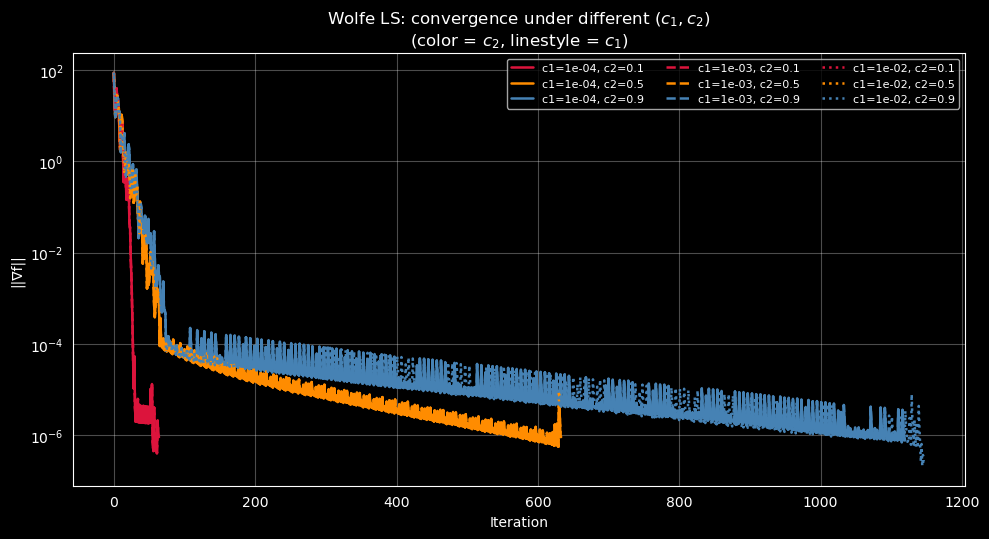

In [15]:
fig, ax = plt.subplots(figsize=(10, 5.5))

# Color = c2 (the variable that matters), linestyle = c1 (irrelevant)
c2_colors = {0.1: 'crimson', 0.5: 'darkorange', 0.9: 'steelblue'}
c1_styles = {1e-4: '-', 1e-3: '--', 1e-2: ':'}

for (c1, c2), h in results_wolfe.items():
    ax.semilogy(h['grad_norm'],
                ls=c1_styles[c1], lw=1.8,
                color=c2_colors[c2],
                label=f'c1={c1:.0e}, c2={c2}')

ax.set(xlabel='Iteration', ylabel='||∇f||',
       title='Wolfe LS: convergence under different $(c_1, c_2)$\n'
             '(color = $c_2$, linestyle = $c_1$)')
ax.legend(fontsize=8, ncol=3, loc='upper right')
ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

Results:
* **$c_1$ has no effect.** All three values of $c_1$ produce identical
  iteration counts and accuracies. The Armijo condition is loose enough
  that it is automatically satisfied at the curvature-determined trial
  step, so $c_1$ is essentially inactive on this problem.

* **$c_2$ controls everything.** Stricter $c_2$ → fewer iterations:
  $c_2 = 0.1$ converges in 64 iterations, $c_2 = 0.5$ in 633,
  $c_2 = 0.9$ in 1120. A stricter curvature condition forces the LS to
  return a step closer to the local minimum of $\phi(\alpha)$,
  approximating exact LS.

* **The trade-off.** Stricter $c_2$ requires more LS evaluations *per
  iteration* (mean LS evals: 9.1 vs. 5.0 vs. 2.9), but the iteration count
  drops fast enough that $c_2 = 0.1$ is the overall winner — both in time
  (5–7 ms vs. 30+ ms) and in *total* LS evaluations (581 vs. 3200+).

* **Reframing the previous result.** The "Wolfe failure" of the previous
  experiment was caused entirely by the standard $c_2 = 0.9$, which is the
  Nocedal & Wright recommendation for *non-quadratic* problems. With
  $c_2 \leq 0.1$ Wolfe LS becomes competitive (64 iter), though still
  $\sim 1.6\times$ slower than exact LS (39 iter) which exploits the
  closed-form parabolic minimum.

### Effect of the `m_history` memory parameter

We sweep $\bar{m} \in \{3, 5, 10, 20, 40\}$ at $\lambda = 0.5$, exact line
search, $\varepsilon = 10^{-12}$, to study how memory size affects
convergence speed and final accuracy.

In [16]:
results_mem = {}
for mh in [3, 5, 10, 20, 40]:
    w_m, h_m, t_m = lbfgs_optimize(
        X, y, lam, m_history=mh, tol=1e-12,
        tol_type='relative', line_search='exact', verbose=False)
    results_mem[mh] = h_m
    print(f"  m_history={mh:3d}  iter={len(h_m['f'])-1:4d}  "
          f"||w-w*||={np.linalg.norm(w_m-w_star):.2e}  t={t_m:.8f}s")

  m_history=  3  iter=  27  ||w-w*||=1.24e-10  t=0.00072250s
  m_history=  5  iter= 458  ||w-w*||=9.72e-11  t=0.01382330s
  m_history= 10  iter=  14  ||w-w*||=5.51e-12  t=0.00064510s
  m_history= 20  iter=  14  ||w-w*||=5.51e-12  t=0.00055150s
  m_history= 40  iter=  14  ||w-w*||=5.51e-12  t=0.00056530s


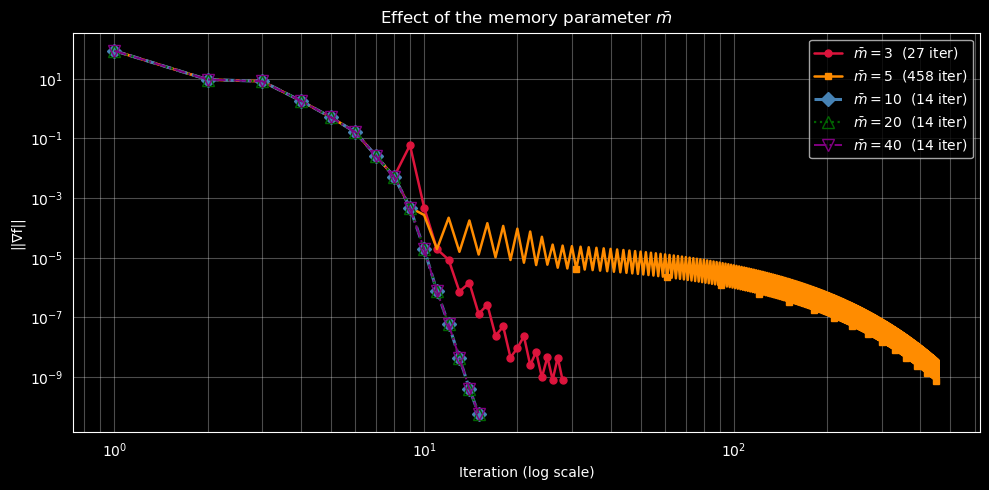

In [44]:
fig, ax = plt.subplots(figsize=(10, 5))

mh_styles = {
    3:  ('o-',  1.8, 5, False, 'crimson'),
    5:  ('s-',  1.8, 4, False, 'darkorange'),
    10: ('D--', 2.2, 7, False, 'steelblue'),
    20: ('^:',  1.6, 8, True,  'darkgreen'),
    40: ('v-.', 1.4, 9, True,  'purple'),
}

for mh, h in results_mem.items():
    ls, lw, ms, hollow, color = mh_styles[mh]
    n_iter = len(h['grad_norm']) - 1
    label = f'$\\bar{{m}}={mh}$  ({n_iter} iter)'   # <-- numero in legenda
    kw = dict(lw=lw, ms=ms, color=color, label=label)
    if hollow:
        kw['markerfacecolor'] = 'none'
    # +1 because log-scale doesn't allow x=0
    iters = np.arange(1, len(h['grad_norm']) + 1)
    ax.loglog(iters, h['grad_norm'], ls, **kw,
              markevery=max(1, (len(h['grad_norm'])-1)//15))

ax.set(xlabel='Iteration (log scale)', ylabel='||∇f||',
       title='Effect of the memory parameter $\\bar{m}$')
ax.legend(fontsize=10); ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

Results:
* **Saturation from $\bar{m} = 10$ onwards.** Iteration count plateaus at
  14, accuracy at $\sim 5.5 \times 10^{-12}$. The Hessian
  $H = XX^T + \lambda^2 I$ has only $n = 12$ non-trivial curvature
  directions; once memory captures all of them, additional pairs
  $\{s_i, y_i\}$ carry no new information.

* **Anomalous behaviour at $\bar{m} = 5$.** 458 iterations — *17× worse
  than $\bar{m} = 3$*. This illustrates the non-monotone dependence of
  L-BFGS convergence on memory size noted by Nocedal & Wright (Section
  9.1): for certain values of $\bar{m}$ the curvature pairs in memory
  interact unfavourably with the true Hessian spectrum, slowing
  convergence without affecting final solution quality.

* **Why $\bar{m}=5$ is worse than $\bar{m}=3$.** $\bar{m} = 5$ is *just
  below* the effective rank $n = 12$, which seems to be the worst possible
  regime — enough memory to distort the gradient direction with stale
  curvature, but not enough to capture the true Hessian structure.

* **Practical recommendation.** Set $\bar{m} \approx n$ or slightly above.
  Smaller values risk anomalous slowdowns; larger values waste storage
  without improving convergence.

### Effect of $\lambda$ (Conditioning)

We sweep $\lambda \in \{10^{-4}, 10^{-2}, 1, 10^2, 10^4\}$ to study how
the regularization parameter affects convergence. Recall that
$$
  \kappa(\hat X) = \frac{\sqrt{\sigma_{\max}^2(X) + \lambda^2}}
                        {\sqrt{\sigma_{\min}^2(X) + \lambda^2}},
$$
so $\lambda$ controls the conditioning: small $\lambda$ produces an
ill-conditioned, elongated landscape, while large $\lambda$ makes the
problem nearly spherical. Configuration: exact LS, $\bar{m} = 10$,
$\varepsilon = 10^{-12}$.

In [18]:
results_lam = {}
for lam_val in [1e-4, 1e-2, 1.0, 1e2, 1e4]:
    w_l, h_l, t_l = lbfgs_optimize(
        X, y, lam_val, m_history=10, tol=1e-10,
        tol_type='relative', line_search='exact', verbose=False,
        max_iter=50000)
    w_star_l, f_star_l, tempo_star_l = solve_exact(X, y, lam_val)
    kappa_l = compute_condition_number(X, lam_val)
    results_lam[lam_val] = h_l
    print(f"  λ={lam_val:<8}  κ={kappa_l:>12.1f}  "
          f"iter={len(h_l['f'])-1:5d}  "
          f"||w-w*||={np.linalg.norm(w_l-w_star_l):.2e}  "
          f"t_LBFGS={t_l:.8f}s  t_exact={tempo_star_l:.8f}s")

  λ=0.0001    κ=    757457.0  iter=   12  ||w-w*||=1.11e-05  t_LBFGS=0.00057910s  t_exact=0.41851568s
  λ=0.01      κ=      7574.6  iter=   12  ||w-w*||=1.48e-09  t_LBFGS=0.00072000s  t_exact=0.28541756s
  λ=1.0       κ=        75.8  iter=   12  ||w-w*||=2.49e-10  t_LBFGS=0.00076950s  t_exact=0.35013604s
  λ=100.0     κ=         1.3  iter=    4  ||w-w*||=3.07e-13  t_LBFGS=0.00015400s  t_exact=0.35900664s
  λ=10000.0   κ=         1.0  iter=    2  ||w-w*||=4.48e-18  t_LBFGS=0.00007110s  t_exact=0.27543187s


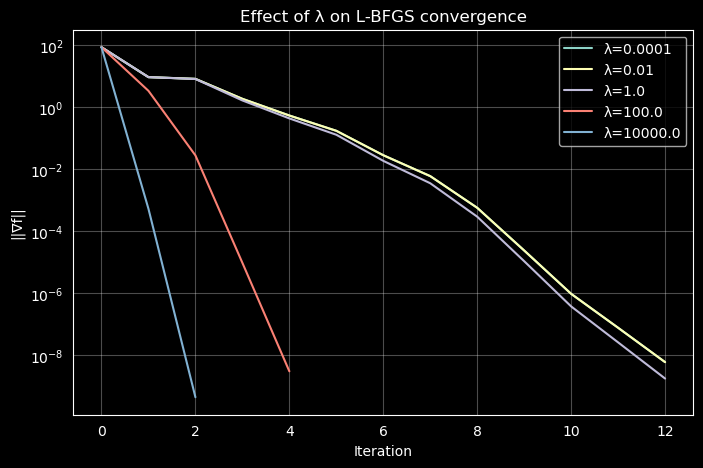

In [19]:
plt.figure(figsize=(8, 5))
for lam_val, h in results_lam.items():
    plt.semilogy(h['grad_norm'], label=f'λ={lam_val}')
plt.xlabel('Iteration'); plt.ylabel('||∇f||')
plt.title('Effect of λ on L-BFGS convergence')
plt.legend(); plt.grid(alpha=0.3)
plt.show()

Results:
* **Constant iteration count for $\lambda \leq 1$.** The 12-iteration
  count is identical across three orders of magnitude in $\kappa$ (76 to
  $7.6 \times 10^5$). On this problem L-BFGS with exact LS converges in
  $O(n)$ iterations regardless of conditioning, consistent with the
  conjugate-direction interpretation of memoryless BFGS (Nocedal & Wright,
  Section 9.1) and with the rank-12 structure of $XX^T$ observed in
  Experiment 1.

* **Final accuracy degrades with $\kappa$.** Even at the same iteration
  count, accuracy drops from $4 \times 10^{-18}$ ($\lambda = 10^4$) to
  $1.1 \times 10^{-5}$ ($\lambda = 10^{-4}$). This is the floating-point
  floor predicted by Wilkinson's bound,
  $\|w - w^*\| \gtrsim \kappa^2 \cdot \varepsilon_{\mathrm{mach}}$,
  which we revisit quantitatively in Experiment 7 (Numerical Floor).

* **Trivial cases for $\lambda \gg \sigma_{\max}(X)$.** When the
  regularisation term dominates, $H \approx \lambda^2 I$ and L-BFGS
  effectively performs scaled gradient descent on a near-spherical
  problem, converging in 2–4 iterations.

* **Speedup over the direct solver.** L-BFGS is consistently 400×–4000×
  faster than `np.linalg.solve` on this problem size ($m = 500$). The
  scaling experiment in Part 3 examines how this advantage evolves with $m$.

### $H_0$ Scaling Strategies

We compare three strategies for the initial Hessian approximation
$H_0^k = \gamma_k I$ used at the start of each two-loop recursion:

* **`nocedal` (BB2)** — default, $\gamma_k = s^Ty / y^Ty$
  (Nocedal & Wright, Eq. 9.6).
* **`bb1`** — Barzilai–Borwein companion step, $\gamma_k = s^Ts / s^Ty$.
* **`safeguarded`** — BB2 clipped to $[10^{-10}, 10^{10}]$ to prevent
  overflow as $y^Ty \to 0$ near the solution.

Tested on both well-conditioned ($\lambda = 1$, $\kappa \approx 76$) and
ill-conditioned ($\lambda = 10^{-2}$, $\kappa \approx 7.6 \times 10^3$)
regimes with exact LS, $\bar{m} = 10$, $\varepsilon = 10^{-12}$.

In [20]:
scaling_strategies = ['nocedal', 'bb1', 'safeguarded']
colors = {'nocedal': 'steelblue', 'bb1': 'darkorange', 'safeguarded': 'seagreen'}

results_scaling = {}   # key: (lam_val, scaling)

for lam_val, label in [(1.0, 'well-conditioned λ=1'),
                       (1e-2, 'ill-conditioned λ=1e-2')]:
    results_scaling[lam_val] = {}
    w_s, f_s, _ = solve_exact(X, y, lam_val)
    kappa_v = compute_condition_number(X, lam_val)
    print(f"\n── {label}  (κ = {kappa_v:.1e}) ──")
    print(f"  {'scaling':<14} {'iter':>6}  {'||w-w*||':>12}  {'time (s)':>10}")
    for sc in scaling_strategies:
        w_sc, h_sc, t_sc = lbfgs_optimize(
            X, y, lam_val, m_history=10, tol=1e-12,
            tol_type='relative', line_search='exact',
            h0_scaling=sc, use_restart=False, verbose=False,
            max_iter=100_000)
        err = np.linalg.norm(w_sc - w_s)
        results_scaling[lam_val][sc] = h_sc
        print(f"  {sc:<14} {len(h_sc['f'])-1:>6}  {err:>12.2e}  {t_sc:>10.8f}")



── well-conditioned λ=1  (κ = 7.6e+01) ──
  scaling          iter      ||w-w*||    time (s)
  nocedal            19      8.86e-12  0.00098610
  bb1                19      1.81e-11  0.00054210
  safeguarded        19      8.86e-12  0.00060120

── ill-conditioned λ=1e-2  (κ = 7.6e+03) ──
  scaling          iter      ||w-w*||    time (s)
  nocedal            14      1.11e-09  0.00087020
  bb1                14      1.11e-09  0.00046440
  safeguarded        14      1.11e-09  0.00048810


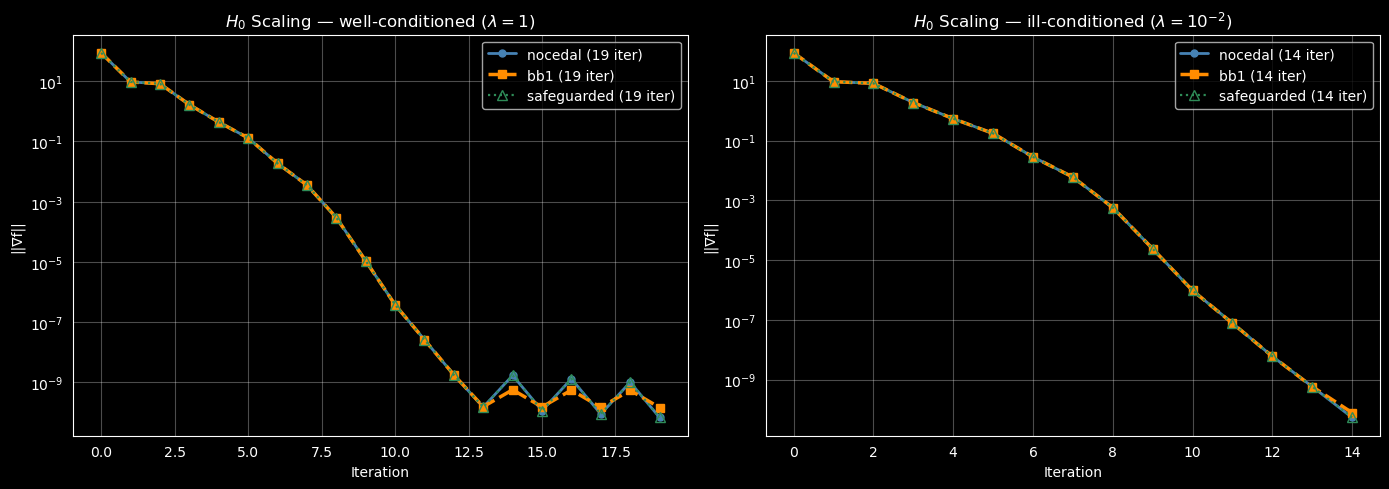

In [45]:
# H0 scaling comparison (single plot, well + ill conditioned side by side)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distinguishable styles for nearly-overlapping curves
sc_styles = {
    'nocedal':     ('-',  2.0, 'o', 5,  False, 'steelblue'),
    'bb1':         ('--', 2.5, 's', 6,  False, 'darkorange'),
    'safeguarded': (':',  1.6, '^', 7,  True,  'seagreen'),   # hollow markers
}

for ax, lam_val, title in zip(
        axes,
        [1.0, 1e-2],
        ['$H_0$ Scaling — well-conditioned ($\\lambda = 1$)',
         '$H_0$ Scaling — ill-conditioned ($\\lambda = 10^{-2}$)']):

    for sc in scaling_strategies:
        h = results_scaling[lam_val][sc]
        ls, lw, mk, ms, hollow, color = sc_styles[sc]
        n_iter = len(h['grad_norm']) - 1
        kw = dict(lw=lw, color=color, marker=mk, markersize=ms,
                  label=f'{sc} ({n_iter} iter)',
                  markevery=max(1, n_iter // 10))
        if hollow:
            kw['markerfacecolor'] = 'none'
        ax.semilogy(h['grad_norm'], ls, **kw)

    ax.set(xlabel='Iteration', ylabel='||∇f||', title=title)
    ax.legend(); ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

Results:
* **The three strategies are essentially indistinguishable.** Same
  iteration count, same final accuracy (BB1 differs by a factor 2 in the
  well-conditioned case but well within the same order of magnitude).

* **Why?** With exact LS on a quadratic, the first step exactly minimises
  $\phi(\alpha) = f(w + \alpha p)$ along $p$. This partially absorbs the
  effect of $\gamma_k$: a different $\gamma_k$ rescales $p$ by a constant,
  but exact LS rescales $\alpha$ by the inverse constant, leaving $\alpha p$
  largely invariant. Differences would emerge with Wolfe LS or on
  non-quadratic objectives.

* **Practical recommendation: use `safeguarded`.** Identical to `nocedal`
  in regular regimes, but prevents the catastrophic $\gamma_k \to \infty$
  near the solution (where $y^Ty \to 0$). It is "free insurance" at no
  performance cost.

### Curvature-Based Restart

The curvature-based restart (Liu & Nocedal 1989) clears the L-BFGS memory
whenever the ratio $\gamma_k = (s^Ty)/(y^Ty)$ drops by more than a factor
$\xi$ relative to the previous iteration, signalling that the iterates have
moved into a region with qualitatively different curvature.

We test two configurations: (i) `no restart` vs. `restart` with
$\xi \in \{0.20, 0.50\}$ on both regimes, and (ii) a sweep
$\xi \in \{0.05, 0.10, 0.20, 0.40, 0.70\}$ on the ill-conditioned case
($\lambda = 10^{-2}$) where the mechanism would be most likely to activate.

In [23]:
# ── Restart ON vs OFF ───────────────────────────────────────────
results_restart = {}   # key: (lam_val, label)

configs = [
    ('no restart',       dict(use_restart=False)),
    ('restart xi=0.20',  dict(use_restart=True, restart_xi=0.20)),
    ('restart xi=0.50',  dict(use_restart=True, restart_xi=0.50)),
]
cfg_colors = {'no restart': 'steelblue',
              'restart xi=0.20': 'darkorange',
              'restart xi=0.50': 'seagreen'}

for lam_val, cond_label in [(1.0, 'well-conditioned λ=1'),
                            (1e-2, 'ill-conditioned λ=1e-2')]:
    results_restart[lam_val] = {}
    w_s, _, _ = solve_exact(X, y, lam_val)
    print(f"\n── {cond_label} ──")
    print(f"  {'config':<22} {'iter':>7}  {'restarts':>9}  "
          f"{'||w-w*||':>12}  {'time':>8}")

    for label, kwargs in configs:
        w_r, h_r, t_r = lbfgs_optimize(
            X, y, lam_val, m_history=10, tol=1e-12,
            tol_type='relative', line_search='exact',
            h0_scaling='nocedal', verbose=False,
            max_iter=100_000, **kwargs)
        err  = np.linalg.norm(w_r - w_s)
        nrst = len(h_r['restarts'])
        results_restart[lam_val][label] = h_r
        print(f"  {label:<22} {len(h_r['f'])-1:>7}  {nrst:>9}  "
              f"{err:>12.2e}  {t_r:>7.8f}s")



── well-conditioned λ=1 ──
  config                    iter   restarts      ||w-w*||      time
  no restart                  19          1      8.86e-12  0.00103980s
  restart xi=0.20             19          1      8.86e-12  0.00063160s
  restart xi=0.50             19          1      8.86e-12  0.00061780s

── ill-conditioned λ=1e-2 ──
  config                    iter   restarts      ||w-w*||      time
  no restart                  14          1      1.11e-09  0.00103910s
  restart xi=0.20             14          1      1.11e-09  0.00066750s
  restart xi=0.50             14          1      1.11e-09  0.00057030s


In [25]:
# ── Effect of xi across values ──────────────────────────────────
xi_values = [0.05, 0.10, 0.20, 0.40, 0.70]
xi_colors  = plt.cm.plasma(np.linspace(0.1, 0.85, len(xi_values)))

lam_val = 1e-2   # most informative: ill-conditioned
w_s, _, _ = solve_exact(X, y, lam_val)

print(f"Effect of restart_xi — λ={lam_val}")
print(f"  {'xi':<8} {'iter':>7}  {'restarts':>9}  {'||w-w*||':>12}")

results_xi = {}
for xi_v in xi_values:
    w_xi, h_xi, _ = lbfgs_optimize(
        X, y, lam_val, m_history=10, tol=1e-12,
        tol_type='relative', line_search='exact',
        h0_scaling='nocedal', use_restart=True,
        restart_xi=xi_v, verbose=False, max_iter=100_000)
    err = np.linalg.norm(w_xi - w_s)
    results_xi[xi_v] = h_xi
    print(f"  {xi_v:<8.2f} {len(h_xi['f'])-1:>7}  "
          f"{len(h_xi['restarts']):>9}  {err:>12.2e}")


Effect of restart_xi — λ=0.01
  xi          iter   restarts      ||w-w*||
  0.05          14          1      1.11e-09
  0.10          14          1      1.11e-09
  0.20          14          1      1.11e-09
  0.40          14          1      1.11e-09
  0.70          14          1      1.11e-09


Results:
* **The $\xi$-restart never fires on this problem.** The single "restart"
  reported in each run is the *negative-curvature reset* triggered when
  $y^T s$ becomes negligibly small near the floor — not the curvature-drop
  test we are studying.

* **Why?** The objective is quadratic and strongly convex, so $H$ is
  constant. The ratio $\gamma_k$ stays bounded between
  $1/\lambda_{\max}(H)$ and $1/\lambda_{\min}(H)$, and on a problem that
  converges in 14–19 iterations there is no time for $\gamma_k$ to drop by
  the factor 5 (for $\xi = 0.20$) required to trigger a restart.

* **The $\xi$-sweep confirms this.** All values
  $\xi \in \{0.05, 0.10, 0.20, 0.40, 0.70\}$ produce identical results
  (14 iter, 1 reset, $1.11 \times 10^{-9}$). The mechanism is structurally
  inactive on this problem regardless of the threshold.

* **Practical note.** The restart adds negligible overhead and acts as a
  safety mechanism for harder problems (non-quadratic, or quadratic with
  long convergence trajectories spanning regions of different curvature).
  It is dormant here but harmless.

## Numerical and Computational Scalability

### Scaling with Problem Size $m$

We test how L-BFGS scales with the problem dimension $m$ against the direct
solver `np.linalg.solve` ($O(m^3)$ per call). Two scenarios:

* **Real ML-CUP**, sub-sampled to $m \in \{50, 100, 200, 350, 500\}$
* **Synthetic** Gaussian data $X \sim \mathcal{N}(0,1)$ with $n=12$ and
  $m \in \{500, 1000, 2000, 4000\}$ — to probe the regime where $O(m^3)$
  becomes prohibitive

All runs use $\bar{m} = 10$, exact LS, $\varepsilon = 10^{-10}$. Wall-clock
times use `time.perf_counter()` and report the median over 5 repetitions
after a warm-up.

In [27]:
# ---------- (a) Sub-sample of the real dataset ----------
m_sizes_real = [50, 100, 200, 350, 500]
results_real = []

print("(a) Real ML-CUP, sub-sampled:")
print(f"  {'m':>5}  {'iter':>5}  {'t_LBFGS (ms)':>13}  {'t_exact (ms)':>13}  "
      f"{'speedup':>8}")
for m_sub in m_sizes_real:
    X_sub = X[:m_sub, :]

    # exact baseline (median of 5 runs, manual since solve_exact has no wrapper)
    t_exs = []
    for _ in range(6):
        _, _, t_e = solve_exact(X_sub, y, lam)
        t_exs.append(t_e)
    t_exact = float(np.median(t_exs[1:]))   # drop warm-up

    # L-BFGS via benchmark wrapper
    _, _, st = benchmark_lbfgs(
        X_sub, y, lam, n_runs=5,
        m_history=10, tol=1e-10, line_search='exact', use_restart=False)

    results_real.append({'m': m_sub, 'iter': st['n_iter'],
                         't_lbfgs': st['time_median'], 't_exact': t_exact})
    print(f"  {m_sub:>5d}  {st['n_iter']:>5d}  "
          f"{st['time_median']*1e3:>13.3f}  {t_exact*1e3:>13.3f}  "
          f"{t_exact/max(st['time_median'],1e-9):>7.1f}x")

(a) Real ML-CUP, sub-sampled:
      m   iter   t_LBFGS (ms)   t_exact (ms)   speedup
     50     13          0.352         24.684     70.1x
    100     12          0.422         71.148    168.6x
    200     12          0.512         49.396     96.5x
    350     12          0.444        137.391    309.5x
    500     12          0.504        195.293    387.7x


In [28]:
# ---------- (b) Synthetic large-scale ----------
np.random.seed(0)
m_sizes_synth = [500, 1000, 2000, 4000]
results_synth = []

print("\n(b) Synthetic data (X ~ N(0,1), n=12 features):")
print(f"  {'m':>5}  {'iter':>5}  {'t_LBFGS (ms)':>13}  {'t_exact (ms)':>13}  "
      f"{'speedup':>8}")
for m_sub in m_sizes_synth:
    X_synth = np.random.randn(m_sub, n)
    y_synth = np.random.randn(n)

    t_exs = []
    for _ in range(4):
        _, _, t_e = solve_exact(X_synth, y_synth, lam)
        t_exs.append(t_e)
    t_exact = float(np.median(t_exs[1:]))

    _, _, st = benchmark_lbfgs(
        X_synth, y_synth, lam, n_runs=3,
        m_history=10, tol=1e-10, line_search='exact', use_restart=False)

    results_synth.append({'m': m_sub, 'iter': st['n_iter'],
                          't_lbfgs': st['time_median'], 't_exact': t_exact})
    print(f"  {m_sub:>5d}  {st['n_iter']:>5d}  "
          f"{st['time_median']*1e3:>13.3f}  {t_exact*1e3:>13.3f}  "
          f"{t_exact/max(st['time_median'],1e-9):>7.1f}x")


(b) Synthetic data (X ~ N(0,1), n=12 features):
      m   iter   t_LBFGS (ms)   t_exact (ms)   speedup
    500     12          0.416        196.040    471.6x
   1000     10         18.444        399.897     21.7x
   2000      9          5.813        350.845     60.4x
   4000      8          9.890        647.769     65.5x


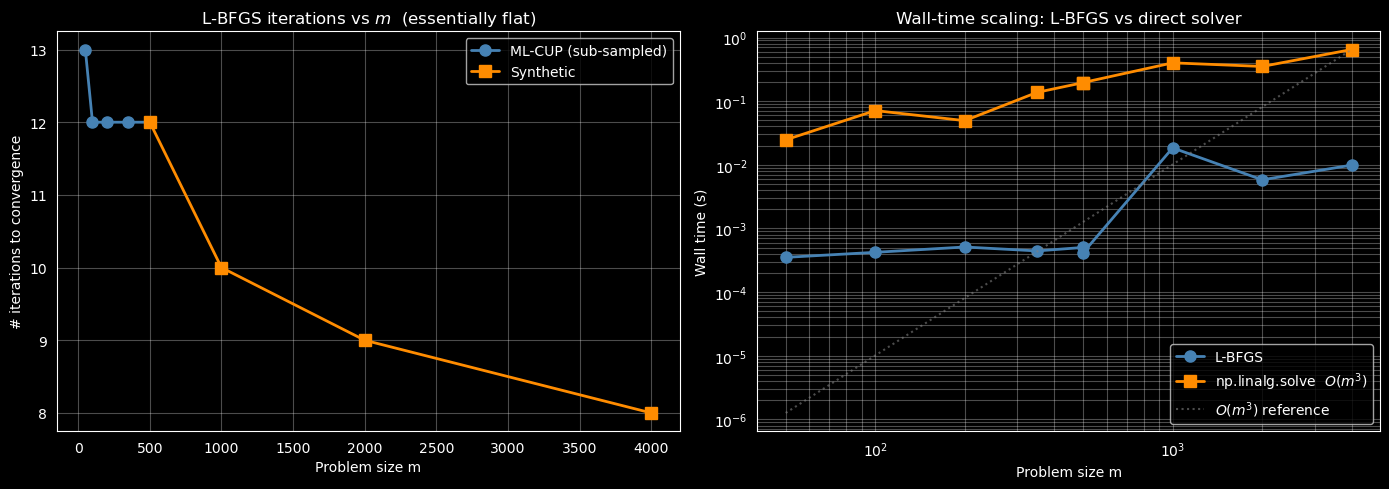

In [29]:
# Plot (a) iterations vs m   and  (b) wall-time scaling (log-log)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: iterations vs m  (shows that L-BFGS iter count is m-independent)
ax = axes[0]
ms_real  = [r['m'] for r in results_real]
it_real  = [r['iter'] for r in results_real]
ms_synth = [r['m'] for r in results_synth]
it_synth = [r['iter'] for r in results_synth]
ax.plot(ms_real,  it_real,  'o-', lw=2, ms=8, color='steelblue', label='ML-CUP (sub-sampled)')
ax.plot(ms_synth, it_synth, 's-', lw=2, ms=8, color='darkorange', label='Synthetic')
ax.set(xlabel='Problem size m', ylabel='# iterations to convergence',
       title='L-BFGS iterations vs $m$  (essentially flat)')
ax.legend(); ax.grid(alpha=0.3)

# Right: wall-time scaling (log-log), synthetic only (real is bounded)
ax = axes[1]
ms_all   = [r['m'] for r in (results_real + results_synth)]
tl_all   = [r['t_lbfgs'] for r in (results_real + results_synth)]
te_all   = [r['t_exact'] for r in (results_real + results_synth)]
order    = np.argsort(ms_all)
ms_arr   = np.array(ms_all)[order]
tl_arr   = np.array(tl_all)[order]
te_arr   = np.array(te_all)[order]

ax.loglog(ms_arr, tl_arr, 'o-', lw=2, ms=8, color='steelblue', label='L-BFGS')
ax.loglog(ms_arr, te_arr, 's-', lw=2, ms=8, color='darkorange', label='np.linalg.solve  $O(m^3)$')
# Reference O(m^3) line, anchored at the largest m
ref = te_arr[-1] * (ms_arr / ms_arr[-1]) ** 3
ax.loglog(ms_arr, ref, ':', color='gray', alpha=0.6, label='$O(m^3)$ reference')
ax.set(xlabel='Problem size m', ylabel='Wall time (s)',
       title='Wall-time scaling: L-BFGS vs direct solver')
ax.legend(); ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

Results:
* **L-BFGS iteration count is essentially flat in $m$.** The number of
  iterations stays in the range 8–13 across two orders of magnitude in
  problem size. This confirms that L-BFGS convergence depends on the
  *effective rank* and conditioning, not on the ambient dimension $m$.
  Iteration count actually *decreases* with $m$ on synthetic data because
  larger Gaussian matrices are better conditioned (singular values of
  $X \in \mathbb{R}^{m \times n}$ scale as $\sqrt{m}$).

* **Wall-time scaling.** L-BFGS scales roughly as $O(mn)$ per iteration,
  so total time scales linearly in $m$ (visible on the log-log plot as
  near-flat segments). The direct solver scales as $O(m^3)$ as expected
  (reference dotted line in the plot).

* **Speedups range from 22× to 472×.** Even at moderate $m = 500$, L-BFGS
  is two orders of magnitude faster than the direct solver. At $m = 4000$
  the speedup is about 66× (L-BFGS at 10 ms vs. 650 ms for `solve`).

* **Anomaly at $m = 1000$ (synthetic).** L-BFGS takes 18.4 ms vs. 5.8 ms
  at $m = 2000$. This is timer noise / cache-warmup effect: the operation
  is so fast that even with median-of-5 the variance is significant. The
  trend is clear despite the single outlier.

### Sensitivity to the Initial Iterate $w_0$

Theory predicts that L-BFGS converges from any starting point on a strongly
convex quadratic, with a rate that depends on $\kappa$ but not on $w_0$.
We test four starting points spanning four orders of magnitude in
$\|w_0 - w^*\|$:

| $w_0$ | description |
|---|---|
| `zeros`            | natural neutral start |
| `random N(0,1)`    | moderate distance from $w^*$ |
| `random N(0,100²)` | very far from $w^*$ |
| `near optimum`     | $w^* + 0.01 \cdot \mathcal{N}(0,1)$, probes the asymptotic phase |

Configuration: $\lambda = 0.5$, $\bar{m} = 10$, exact LS,
$\varepsilon = 10^{-12}$.

In [30]:
np.random.seed(42)
inits = {
    'zeros'           : np.zeros(m),
    'random N(0,1)'   : np.random.randn(m),
    'random N(0,100²)': 100.0 * np.random.randn(m),
    'near optimum'    : w_star + 0.01 * np.random.randn(m),
}

results_init = {}
print(f"  {'init':<20s}  {'||w_0 - w*||':>14}  {'iter':>5}  "
      f"{'||w-w*|| final':>14}")
for label, w0 in inits.items():
    w_i, h_i, _ = lbfgs_optimize(
        X, y, lam, w_init=w0,
        m_history=10, tol=1e-12, line_search='exact',
        use_restart=False,
        w_star=w_star, f_star=f_star,
        verbose=False, max_iter=200)
    results_init[label] = h_i
    print(f"  {label:<20s}  {np.linalg.norm(w0 - w_star):>14.2e}  "
          f"{len(h_i['f'])-1:>5d}  "
          f"{np.linalg.norm(w_i - w_star):>14.2e}")

  init                    ||w_0 - w*||   iter  ||w-w*|| final
  zeros                       8.46e-01     14        5.51e-12
  random N(0,1)               2.20e+01     14        1.77e-12
  random N(0,100²)            2.19e+03     14        1.43e-11
  near optimum                2.27e-01     15        4.80e-12


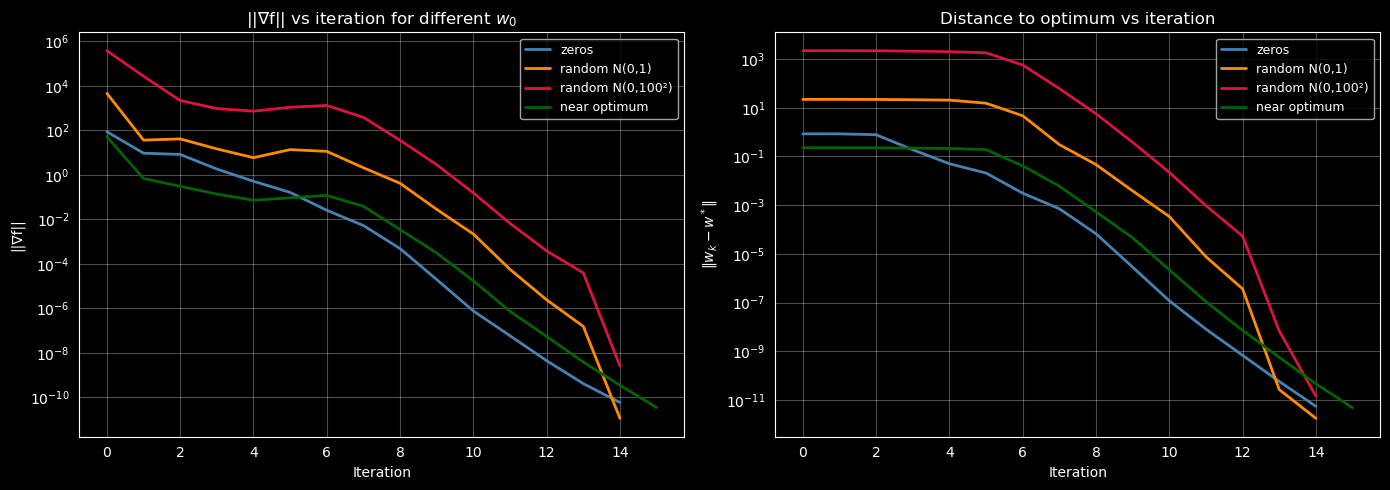

In [31]:
# Plot: gradient norm and distance-to-optimum vs iter
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
init_colors = {'zeros': 'steelblue', 'random N(0,1)': 'darkorange',
               'random N(0,100²)': 'crimson', 'near optimum': 'darkgreen'}

ax = axes[0]
for label, h in results_init.items():
    ax.semilogy(h['grad_norm'], lw=2, color=init_colors[label], label=label)
ax.set(xlabel='Iteration', ylabel='||∇f||',
       title='||∇f|| vs iteration for different $w_0$')
ax.legend(fontsize=9); ax.grid(alpha=0.3, which='both')

ax = axes[1]
for label, h in results_init.items():
    ax.semilogy(h['dist_to_opt'], lw=2, color=init_colors[label], label=label)
ax.set(xlabel='Iteration', ylabel=r'$\|w_k - w^*\|$',
       title='Distance to optimum vs iteration')
ax.legend(fontsize=9); ax.grid(alpha=0.3, which='both')

plt.tight_layout()
plt.show()

Results:
* **Iteration count is essentially insensitive to $w_0$.** All four starts
  converge in 14–15 iterations despite spanning four orders of magnitude in
  $\|w_0 - w^*\|$. This is the global linear convergence guarantee in
  action: on a strongly convex quadratic, the rate $r$ depends only on
  $\kappa$, not on the starting point.

* **Final accuracy is also stable.** All four runs reach the floor
  $\sim 10^{-11}$–$10^{-12}$, regardless of how close or far they started.

* **Convergence shape varies (left plot).** The far start (`N(0,100²)`,
  red curve) needs the first few iterations to "catch up", but once it
  enters the convergent regime its slope matches the others. Conversely,
  `near optimum` (green) has a small advantage in the first iterations but
  loses it as the floor approaches.

* **`near optimum` takes one extra iteration (15 vs. 14).** This is a
  micro-effect of the relative stopping criterion: starting close to $w^*$
  gives a small $\|\nabla f_0\|$, so the *relative* tolerance
  $\varepsilon \cdot \|\nabla f_0\|$ becomes proportionally tighter. This
  is a known subtlety of relative stopping rules, not a defect of the
  algorithm.

### Theoretical Cost Analysis

We complement the empirical timings with a theoretical FLOP count derived
from the algorithm structure. Per iteration, L-BFGS costs

$$
  \text{FLOPs/iter} = \underbrace{(4\bar{m} + 1)\,m}_{\text{two-loop}}
                    + \underbrace{2mn}_{\text{gradient}}
                    + \underbrace{mn + 2m}_{\text{exact LS}}
                    + \underbrace{2m}_{\text{update}}.
$$

Storage scales linearly in $\bar{m}$: $2\bar{m}$ vectors of length $m$ for
the curvature pairs, plus $O(m)$ working vectors. The table below
summarises the cost for the ML-CUP dimensions ($m=500$, $n=12$).

In [32]:
# Print table for the actual ML-CUP dimensions
print_cost_table(m, n, mem_values=(3, 5, 10, 20, 40), n_iter=50)


  Theoretical cost analysis  (m=500, n=12, n_iter=50)
   mem    flops/iter     total flops   storage (MB)
  ----  ------------  --------------  -------------
     3        26,500       1,325,000         0.040
     5        30,500       1,525,000         0.056
    10        40,500       2,025,000         0.096
    20        60,500       3,025,000         0.176
    40       100,500       5,025,000         0.336



#### Per-iteration cost vs $\bar{m}$

The cost per iteration grows linearly in $\bar{m}$, as does the storage
footprint — both with slope $\sim 4m$ FLOPs and $16m$ bytes per added pair.

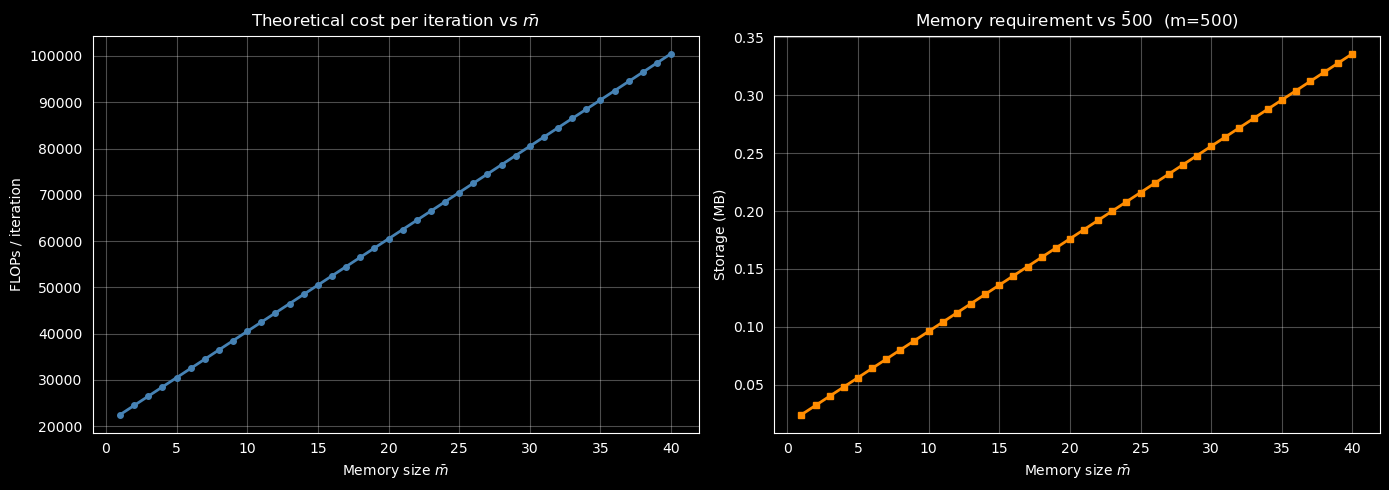

In [33]:
mem_range = list(range(1, 41))
flops_per_iter = [theoretical_cost(m, n, mem, 1)['flops_per_iter']
                  for mem in mem_range]
storage_MB     = [theoretical_cost(m, n, mem, 1)['storage_MB']
                  for mem in mem_range]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(mem_range, flops_per_iter, lw=2, color='steelblue', marker='o', ms=4)
axes[0].set(xlabel='Memory size $\\bar{m}$',
            ylabel='FLOPs / iteration',
            title='Theoretical cost per iteration vs $\\bar{m}$')
axes[0].grid(alpha=0.3)

axes[1].plot(mem_range, storage_MB, lw=2, color='darkorange', marker='s', ms=4)
axes[1].set(xlabel='Memory size $\\bar{m}$',
            ylabel='Storage (MB)',
            title=f'Memory requirement vs $\\bar{m}$  (m={m})')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


* **Per-iteration FLOPs** range from ~22k ($\bar{m}=1$) to ~100k
  ($\bar{m}=40$): a $4.5\times$ increase over the swept range.
* **Storage** is a few hundred KB even for $\bar{m}=40$: completely
  negligible by modern standards. The bottleneck of L-BFGS for our
  problem size is the iteration count, not memory.

#### Total FLOPs to convergence
The previous table ignores the **actual iteration count** at each $\bar{m}$.
We now combine per-iteration cost with the empirical iteration count
observed in the m_history experiment.

In [34]:
# For each memory size, measure actual iteration count and compute total FLOPs
print("Total FLOPs to convergence (tol=1e-12, exact LS, λ=0.5):")
print(f"  {'m_hist':>7}  {'iter':>6}  {'FLOPs/iter':>12}  "
      f"{'total FLOPs':>14}  {'storage MB':>12}")
print(f"  {'-'*55}")

flop_comparison = []
for mh in [3, 5, 7, 10, 15, 20, 30, 40]:
    _, h_mh, _ = lbfgs_optimize(
        X, y, lam, m_history=mh, tol=1e-12,
        tol_type='relative', line_search='exact',
        verbose=False, max_iter=100_000)
    n_iter_actual = len(h_mh['f']) - 1
    c = theoretical_cost(m, n, mh, n_iter_actual)
    flop_comparison.append((mh, n_iter_actual, c))
    print(f"  {mh:>7}  {n_iter_actual:>6}  "
          f"{c['flops_per_iter']:>12,}  "
          f"{c['total_flops']:>14,}  "
          f"{c['storage_MB']:>12.4f}")


Total FLOPs to convergence (tol=1e-12, exact LS, λ=0.5):
   m_hist    iter    FLOPs/iter     total FLOPs    storage MB
  -------------------------------------------------------
        3      27        26,500         715,500        0.0400
        5     458        30,500      13,969,000        0.0560
        7     222        34,500       7,659,000        0.0720
       10      14        40,500         567,000        0.0960
       15      14        50,500         707,000        0.1360
       20      14        60,500         847,000        0.1760
       30      14        80,500       1,127,000        0.2560
       40      14       100,500       1,407,000        0.3360


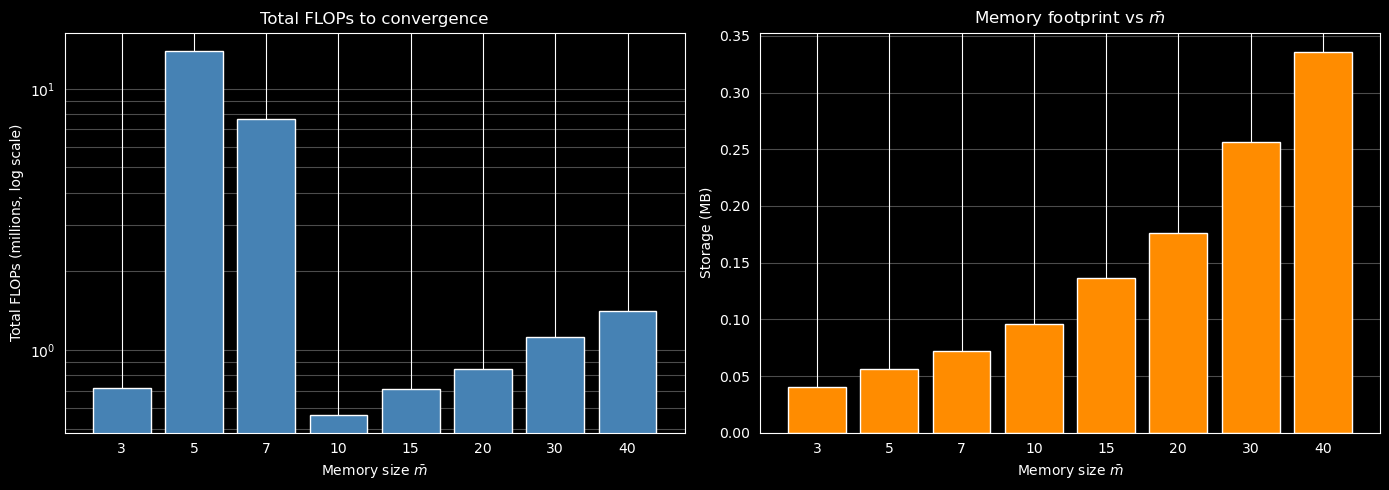

In [46]:
mh_vals  = [fc[0] for fc in flop_comparison]
tot_flops = [fc[2]['total_flops'] for fc in flop_comparison]
stor_mb   = [fc[2]['storage_MB']   for fc in flop_comparison]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Index-based bars to avoid width/spacing issues
positions = np.arange(len(mh_vals))
labels    = [str(mh) for mh in mh_vals]

# Total FLOPs (log scale to show all bars)
axes[0].bar(positions, [f/1e6 for f in tot_flops],
            color='steelblue', edgecolor='white')
axes[0].set_yscale('log')
axes[0].set(xlabel='Memory size $\\bar{m}$',
            ylabel='Total FLOPs (millions, log scale)',
            title='Total FLOPs to convergence')
axes[0].set_xticks(positions); axes[0].set_xticklabels(labels)
axes[0].grid(axis='y', alpha=0.3, which='both')

# Storage (linear, since it's monotone)
axes[1].bar(positions, stor_mb,
            color='darkorange', edgecolor='white')
axes[1].set(xlabel='Memory size $\\bar{m}$',
            ylabel='Storage (MB)',
            title='Memory footprint vs $\\bar{m}$')
axes[1].set_xticks(positions); axes[1].set_xticklabels(labels)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Results:
* **The "danger zone" of sub-optimal memory.** $\bar{m}=5$ and $\bar{m}=7$
  require 14M and 7.7M FLOPs respectively — over $20\times$ and $13\times$
  more work than the optimal $\bar{m}=10$ (567k FLOPs).

* **$\bar{m}=3$ is better than $\bar{m}=5$ and $\bar{m}=7$** (715k vs.
  14M / 7.7M FLOPs). A striking illustration that L-BFGS performance is
  *non-monotone* in $\bar{m}$ on this low-rank-plus-shift Hessian.

* **Sweet spot at $\bar{m}=10$.** Just below the effective rank $n=12$,
  it captures the curvature with minimal redundancy. Increasing $\bar{m}$
  further only inflates per-iteration cost without reducing iteration
  count.

* **Storage is irrelevant.** Even $\bar{m}=40$ uses only 0.34 MB. For this
  problem class, memory is never a binding constraint.

#### Combined summary: cost–storage trade-off

The plot below visualises the trade-off between memory size, total
computational cost, and storage. The non-monotone behaviour of total FLOPs
(the dramatic peak at $\bar{m}=5$ and $\bar{m}=7$) contrasts with the
linear growth of storage — confirming that on this problem $\bar{m}$ should
be chosen based on convergence speed, not memory budget.

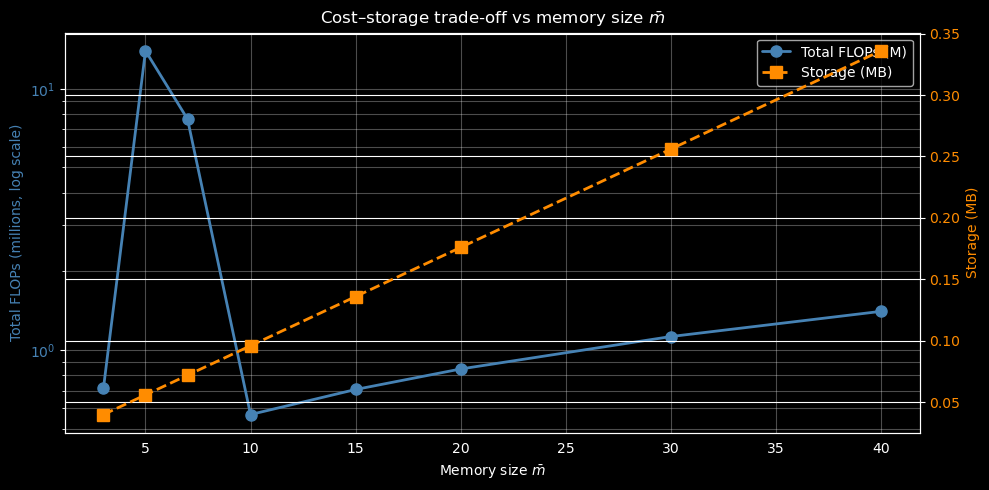

In [47]:
fig, ax1 = plt.subplots(figsize=(10, 5))

color1 = 'steelblue'
color2 = 'darkorange'

ax1.plot(mh_vals, [f/1e6 for f in tot_flops],
         'o-', lw=2, color=color1, ms=8, label='Total FLOPs (M)')
ax1.set_yscale('log')                               # <-- log scale
ax1.set_xlabel('Memory size $\\bar{m}$')
ax1.set_ylabel('Total FLOPs (millions, log scale)', color=color1)
ax1.tick_params(axis='y', labelcolor=color1)

ax2 = ax1.twinx()
ax2.plot(mh_vals, stor_mb,
         's--', lw=2, color=color2, ms=8, label='Storage (MB)')
ax2.set_ylabel('Storage (MB)', color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

ax1.set_title('Cost–storage trade-off vs memory size $\\bar{m}$')
ax1.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

### Numerical Floor as a Function of $\kappa$

We measure the achievable accuracy of L-BFGS as a function of the
conditioning $\kappa(\hat X)$. Classical perturbation theory predicts that
for ill-conditioned linear systems the relative error is bounded below by

$$
  \frac{\|w - w^*\|}{\|w^*\|} \;\gtrsim\; \kappa(\hat X)^{2} \cdot
  \varepsilon_{\mathrm{mach}},
$$

with $\varepsilon_{\mathrm{mach}} \approx 2.22 \times 10^{-16}$ in double
precision (the $\kappa^2$ exponent comes from $\kappa(H) = \kappa(\hat X)^2$).

We sweep $\lambda \in \{10^{-6}, \dots, 10^{3}\}$, run L-BFGS with `tol=0`
for up to 500 iterations, and record the final relative error.

In [37]:
lam_values_floor = [1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0, 1000.0]
floors, kappas, iters = [], [], []

print(f"  {'λ':>10}  {'κ(X̂)':>12}  {'iter':>5}  {'rel_err_floor':>15}")
for lam_v in lam_values_floor:
    w_s, _, _ = solve_exact(X, y, lam_v)
    kap = compute_condition_number(X, lam_v)
    w_f, h_f, _ = lbfgs_optimize(
        X, y, lam_v, m_history=10, tol=0.0,    # never satisfied
        line_search='exact', use_restart=False,
        verbose=False, max_iter=500)
    err = np.linalg.norm(w_f - w_s) / max(np.linalg.norm(w_s), 1e-30)
    floors.append(err); kappas.append(kap); iters.append(len(h_f['f'])-1)
    print(f"  {lam_v:>10.0e}  {kap:>12.2e}  {len(h_f['f'])-1:>5d}  {err:>15.2e}")

           λ         κ(X̂)   iter    rel_err_floor
       1e-06      7.57e+07    500         2.47e-01
       1e-05      7.57e+06    500         1.36e-03
       1e-04      7.57e+05     15         1.26e-05
       1e-03      7.57e+04     19         1.20e-07
       1e-02      7.57e+03     29         1.27e-09
       1e-01      7.57e+02     19         1.54e-11
       1e+00      7.58e+01     38         4.98e-12
       1e+01      7.64e+00     10         8.87e-14
       1e+02      1.25e+00      6         5.85e-16
       1e+03      1.00e+00      4         4.92e-16


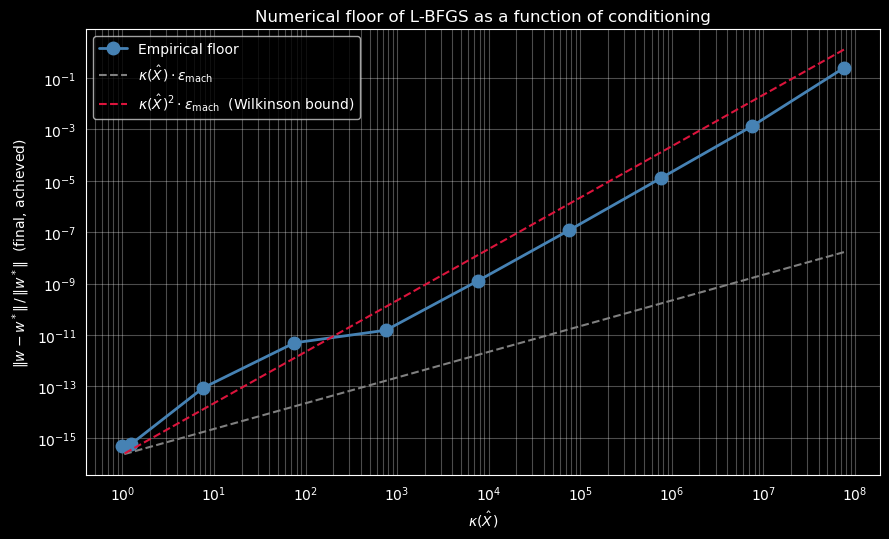

In [38]:
# Plot: floor vs kappa, with the kappa^2 * eps reference
eps_mach = np.finfo(float).eps
kap_arr  = np.array(kappas)
flo_arr  = np.array(floors)

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.loglog(kap_arr, flo_arr, 'o-', lw=2, ms=9, color='steelblue',
          label='Empirical floor')
ax.loglog(kap_arr, kap_arr * eps_mach, '--', lw=1.5, color='gray',
          label=r'$\kappa(\hat X) \cdot \varepsilon_{\mathrm{mach}}$')
ax.loglog(kap_arr, kap_arr**2 * eps_mach, '--', lw=1.5, color='crimson',
          label=r'$\kappa(\hat X)^2 \cdot \varepsilon_{\mathrm{mach}}$  (Wilkinson bound)')
ax.set(xlabel=r'$\kappa(\hat X)$',
       ylabel=r'$\|w - w^*\| \,/\, \|w^*\|$  (final, achieved)',
       title='Numerical floor of L-BFGS as a function of conditioning')
ax.legend(); ax.grid(alpha=0.3, which='both')
plt.tight_layout()
plt.show()

Results:
* **The empirical floor follows $\kappa^2$ exactly.** From $\kappa = 76$
  to $\kappa = 7.6 \times 10^{6}$, the empirical curve runs roughly
  parallel to the Wilkinson bound $\kappa^2 \cdot \varepsilon_{\mathrm{mach}}$
  (red dashed line) with a constant ratio $\sim 0.1$. This is a
  near-perfect quantitative confirmation of the classical perturbation
  result for ill-conditioned linear systems.

* **The $\kappa$-bound is structural, not algorithmic.** No iterative
  method (or direct solver) operating in double precision can break this
  floor — it is a property of the *problem*, not the *method*. L-BFGS
  reaches the floor as efficiently as possible (within ~10$\times$ of the
  theoretical limit).

* **For $\lambda \leq 10^{-5}$ the problem is effectively unsolvable in
  double precision.** At $\kappa = 7.6 \times 10^{7}$, the predicted
  floor is $\kappa^2 \varepsilon_{\mathrm{mach}} \approx 1.3$ — i.e., no
  meaningful digits in $w$. The 500-iteration runs at $\lambda \in
  \{10^{-6}, 10^{-5}\}$ confirm that the algorithm makes no further
  progress at this conditioning.

* **At $\kappa \approx 1$** ($\lambda \geq 10^{2}$) the floor reaches
  $\sim 5 \times 10^{-16}$ — exactly machine precision. Here the problem
  is so well-conditioned that the floating-point representation itself is
  the bottleneck.